In [ ]:
# Data Cleaning

## Project
Global COVID-19 Surveillance & Epidemiological Intelligence Dashboard

## Notebook
02_Data_Cleaning.ipynb

## Objective
This notebook focuses on preparing the COVID-19 surveillance dataset for analysis by:
- Loading the dataset
- Checking data quality
- Converting data types
- Identifying missing values
- Removing duplicate records
- Detecting invalid values
- Saving a cleaned dataset for further analysis

**Author:** Oumar Mahamat
**Date:** July 2026

In [1]:
# ==========================================
# 1. Import Libraries
# ==========================================

import pandas as pd
import numpy as np

In [2]:
# ==========================================
# 2. Load Dataset
# ==========================================

df = pd.read_csv(r"C:\Profile\Data\raw_data.csv")

In [3]:
df_clean = df.copy()

In [4]:
df_clean["Date_reported"] = pd.to_datetime(df_clean["Date_reported"])

In [5]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80160 entries, 0 to 80159
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date_reported       80160 non-null  datetime64[ns]
 1   Country             80160 non-null  object        
 2   WHO_region          74148 non-null  object        
 3   New_cases           51795 non-null  float64       
 4   Cumulative_cases    80160 non-null  int64         
 5   New_deaths          36961 non-null  float64       
 6   Cumulative_deaths   80160 non-null  int64         
 7   Case Fatality Rate  36580 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 4.9+ MB


In [7]:
df_clean.duplicated().sum()

np.int64(0)

In [8]:
df_clean = df_clean.drop_duplicates()

In [9]:
df_clean.duplicated().sum()

np.int64(0)

In [10]:
df_clean.isnull().sum()

Date_reported             0
Country                   0
WHO_region             6012
New_cases             28365
Cumulative_cases          0
New_deaths            43199
Cumulative_deaths         0
Case Fatality Rate    43580
dtype: int64

In [11]:
numeric_columns = [
    "New_cases",
    "Cumulative_cases",
    "New_deaths",
    "Cumulative_deaths"
]

(df_clean[numeric_columns] < 0).sum()

New_cases            18
Cumulative_cases      0
New_deaths           13
Cumulative_deaths     0
dtype: int64

In [12]:
df_clean.to_csv(
    r"C:\Profile\Data\cleaned_covid_data.csv",
    index=False
)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Show the first rows
df.head()

,Date_reported,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,Case Fatality Rate
0,1/5/2020,Armenia,EURO,NaN,0,NaN,0,NaN
1,1/12/2020,Armenia,EURO,NaN,0,NaN,0,NaN
2,1/19/2020,Armenia,EURO,NaN,0,NaN,0,NaN
3,1/26/2020,Armenia,EURO,NaN,0,NaN,0,NaN
4,2/2/2020,Armenia,EURO,NaN,0,NaN,0,NaN


In [14]:
# The number of rows and columns
df.shape

(80160, 8)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80160 entries, 0 to 80159
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date_reported       80160 non-null  object 
 1   Country             80160 non-null  object 
 2   WHO_region          74148 non-null  object 
 3   New_cases           51795 non-null  float64
 4   Cumulative_cases    80160 non-null  int64  
 5   New_deaths          36961 non-null  float64
 6   Cumulative_deaths   80160 non-null  int64  
 7   Case Fatality Rate  36580 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 4.9+ MB


In [16]:
df.describe()

,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
count,5.179500e+04,8.016000e+04,36961.000000,8.016000e+04
mean,1.504446e+04,2.196251e+06,192.505993,2.267150e+04
std,2.352064e+05,8.928053e+06,1007.581380,8.974365e+04
min,-6.507900e+04,0.000000e+00,-3432.000000,0.000000e+00
25%,8.000000e+00,7.749750e+03,0.000000,4.600000e+01
50%,1.410000e+02,6.543500e+04,5.000000,7.980000e+02
75%,1.933000e+03,7.032280e+05,49.000000,8.620000e+03
max,4.047548e+07,1.034368e+08,47687.000000,1.238215e+06


In [20]:
daily_cases = df.groupby('Date_reported')['New_cases'].sum()

daily_cases.head()

Date_reported
1/1/2023     27732700.0
1/10/2021     5007618.0
1/11/2026       14170.0
1/12/2020          45.0
1/12/2025       50012.0
Name: New_cases, dtype: float64

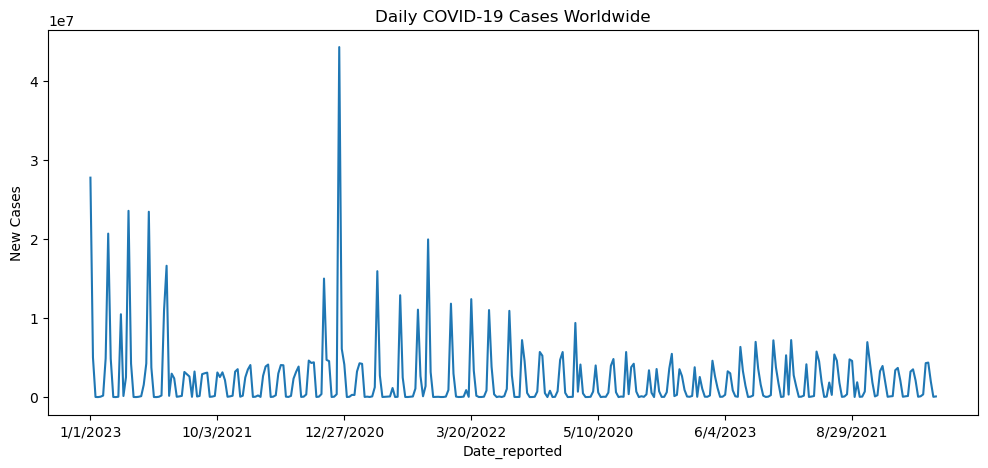

In [21]:
plt.figure(figsize=(12,5))

daily_cases.plot()

plt.title("Daily COVID-19 Cases Worldwide")
plt.xlabel("Date_reported")
plt.ylabel("New Cases")

plt.show()

In [24]:
top_countries = (
    df.groupby('Country')['Cumulative_cases']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

top_countries

Country
United States of America                                103436829
China                                                    99381761
India                                                    45056221
France                                                   39060446
Germany                                                  38437953
Brazil                                                   38026897
Republic of Korea                                        34571873
Japan                                                    33803572
Italy                                                    26969913
United Kingdom of Great Britain and Northern Ireland     25117625
Name: Cumulative_cases, dtype: int64

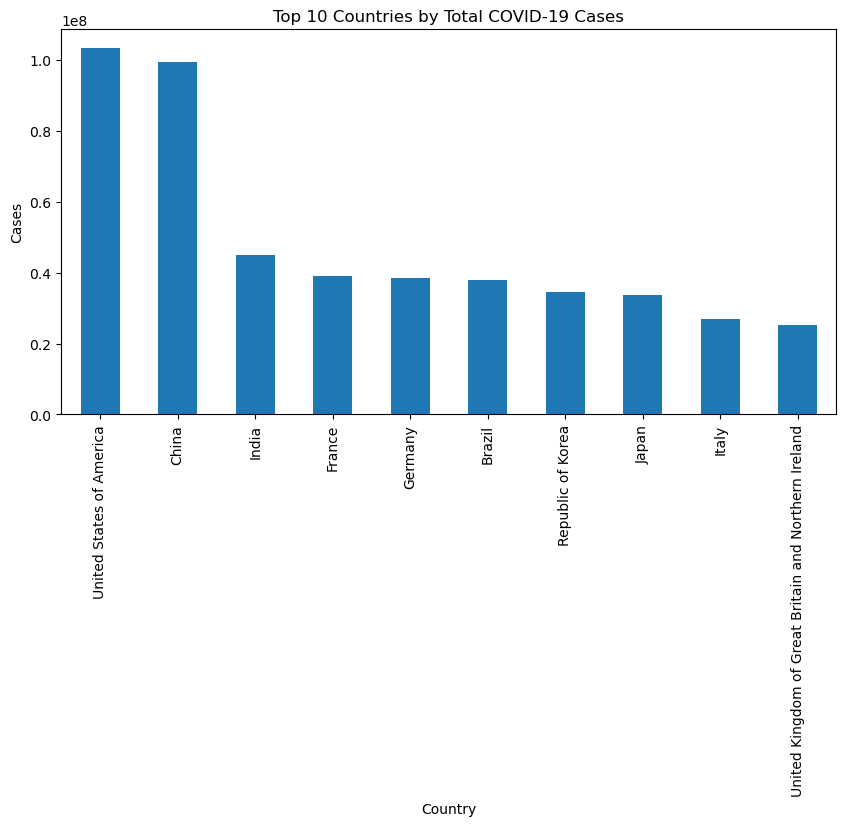

In [25]:
plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Total COVID-19 Cases")
plt.ylabel("Cases")

plt.show()

In [26]:
top_deaths = (
    df.groupby('Country')['Cumulative_deaths']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

top_deaths

Country
United States of America                                1238215
Brazil                                                   703979
India                                                    533849
Russian Federation                                       404290
Mexico                                                   335106
United Kingdom of Great Britain and Northern Ireland     232112
Peru                                                     221071
Italy                                                    198523
Germany                                                  174979
France                                                   168207
Name: Cumulative_deaths, dtype: int64

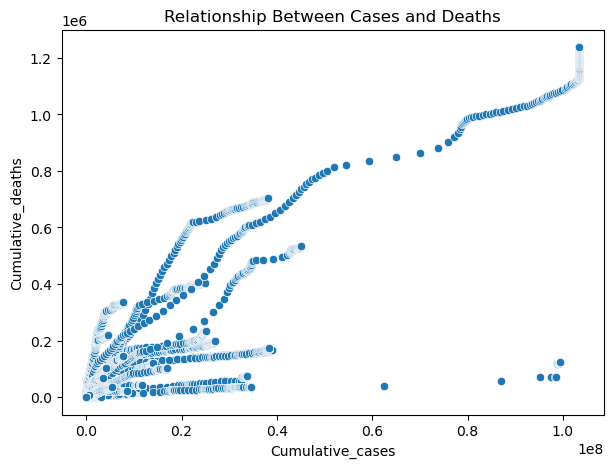

In [27]:
plt.figure(figsize=(7,5))

sns. scatterplot(
    data=df,
    x='Cumulative_cases',
    y='Cumulative_deaths'
)

plt.title("Relationship Between Cases and Deaths")

plt.show()

In [29]:
#Correlation Analysis
correlation = df[
    ['Cumulative_cases',
     'Cumulative_deaths',
     ]
].corr()

correlation

,Cumulative_cases,Cumulative_deaths
Cumulative_cases,1.000000,0.781833
Cumulative_deaths,0.781833,1.000000


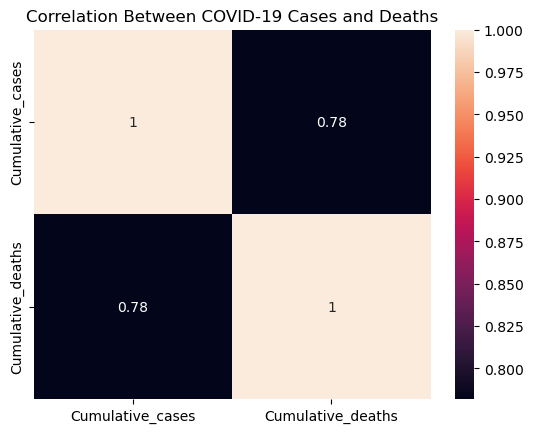

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Between COVID-19 Cases and Deaths")

plt.show()

In [ ]:
#===============
#EDA Findings
#===============

COVID-19 cases increased significantly during 2020–2022 with multiple epidemic waves.
    
A small number of countries contributed to a large proportion of global cases.
    
Total cases showed a positive relationship with deaths.
    
Data quality issues were identified and addressed during cleaning